In [2]:
import pandas as pd

df = pd.read_csv("../Data/customer_sales.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print(df.head())

  Customer_ID Order_Date  Sales
0        C001 2026-09-01   5000
1        C001 2026-09-10   7500
2        C001 2026-09-20  10000
3        C002 2026-08-15   4000
4        C002 2026-09-05   6000


In [3]:
reference_date = pd.Timestamp("2026-09-28")

recency = df.groupby("Customer_ID")["Order_Date"].max()
recency_days = (reference_date - recency).dt.days

frequency = df.groupby("Customer_ID")["Order_Date"].count()

monetary = df.groupby("Customer_ID")["Sales"].sum()

rfm = pd.DataFrame({
    "Recency": recency_days,
    "Frequency": frequency,
    "Monetary": monetary
})

print(rfm)

             Recency  Frequency  Monetary
Customer_ID                              
C001               8          3     22500
C002              23          2     10000
C003              13          4     19500
C004             131          1      2500
C005               6          3     29000


In [4]:
rfm.to_csv("../Outputs/rfm_customer_segments.csv", index=True)

In [5]:
rfm.to_csv("../Outputs/rfm_customer_segments.csv", index=True)

In [6]:


rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

print(rfm.head())

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

print(rfm.head())

             Recency  Frequency  Monetary R_Score F_Score M_Score
Customer_ID                                                      
C001               8          3     22500       4       3       4
C002              23          2     10000       2       2       2
C003              13          4     19500       3       5       3
C004             131          1      2500       1       1       1
C005               6          3     29000       5       4       5
             Recency  Frequency  Monetary R_Score F_Score M_Score
Customer_ID                                                      
C001               8          3     22500       4       3       4
C002              23          2     10000       2       2       2
C003              13          4     19500       3       5       3
C004             131          1      2500       1       1       1
C005               6          3     29000       5       4       5


In [7]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str)
    + rfm["F_Score"].astype(int).astype(str)
    + rfm["M_Score"].astype(int).astype(str)
)

print(rfm.head())

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
Customer_ID                                                                
C001               8          3     22500       4       3       4       434
C002              23          2     10000       2       2       2       222
C003              13          4     19500       3       5       3       353
C004             131          1      2500       1       1       1       111
C005               6          3     29000       5       4       5       545


In [8]:
def assign_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] >= 4 and row["F_Score"] <= 2:
        return "New Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"
    else:
        return "Potential Loyalists"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print(rfm[["Recency", "Frequency", "Monetary", "RFM_Score", "Segment"]].head(10))

             Recency  Frequency  Monetary RFM_Score              Segment
Customer_ID                                                             
C001               8          3     22500       434      Loyal Customers
C002              23          2     10000       222       Lost Customers
C003              13          4     19500       353  Potential Loyalists
C004             131          1      2500       111       Lost Customers
C005               6          3     29000       545            Champions


In [9]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customer_Count"]

print(segment_summary)

               Segment  Customer_Count
0       Lost Customers               2
1      Loyal Customers               1
2  Potential Loyalists               1
3            Champions               1


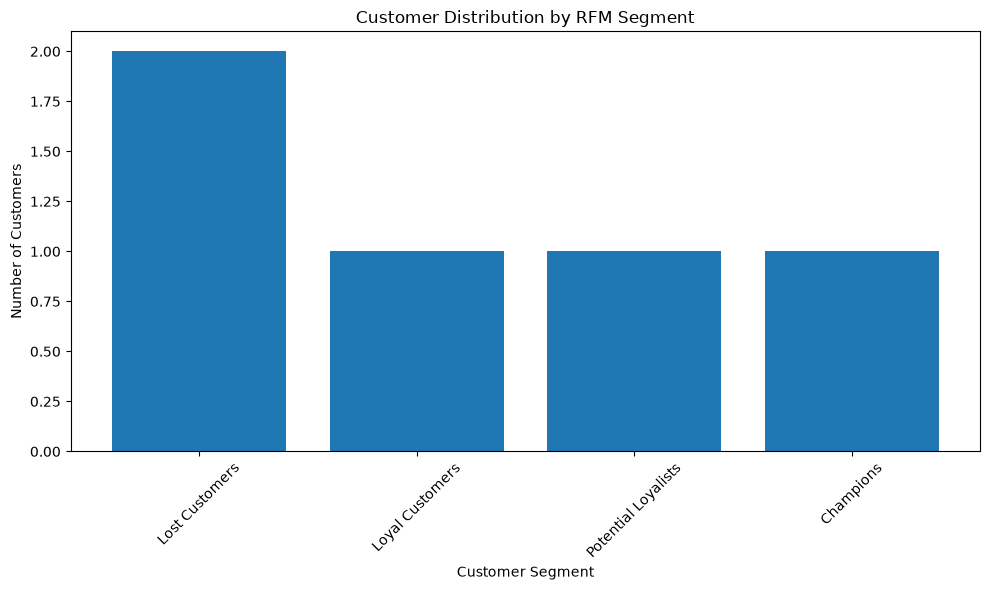

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customer_Count"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
Champions              29000
Loyal Customers        22500
Potential Loyalists    19500
Lost Customers         12500
Name: Monetary, dtype: int64


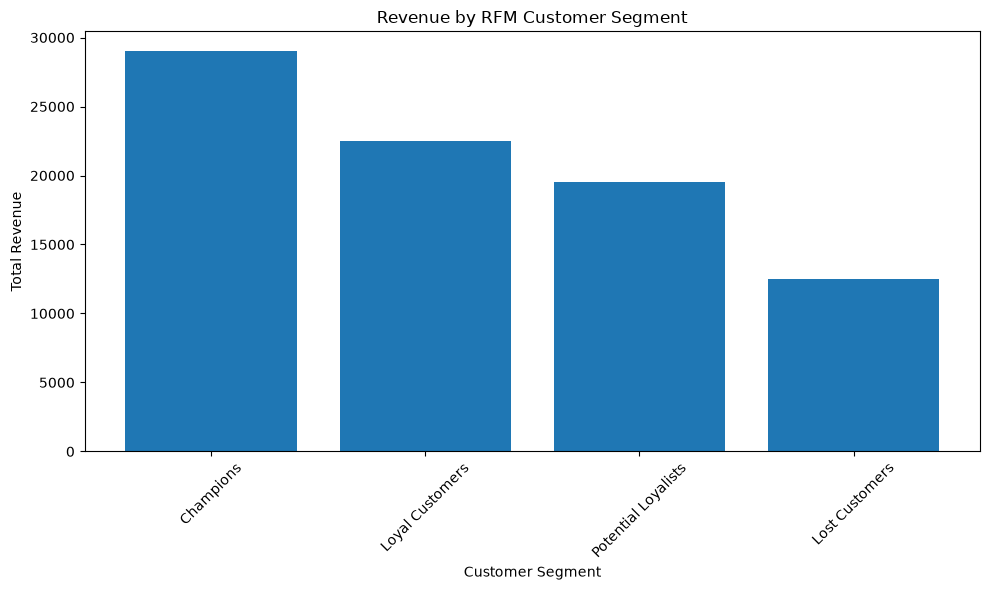

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.title("Revenue by RFM Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
segment_avg_value = (
    rfm.groupby("Segment")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)

print(segment_avg_value)

Segment
Champions              29000.0
Loyal Customers        22500.0
Potential Loyalists    19500.0
Lost Customers          6250.0
Name: Monetary, dtype: float64


In [14]:
final_summary = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score",
        "RFM_Score",
        "Segment"
    ]
]

print(final_summary.head(10))

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
Customer_ID                                                                   
C001               8          3     22500       4       3       4       434   
C002              23          2     10000       2       2       2       222   
C003              13          4     19500       3       5       3       353   
C004             131          1      2500       1       1       1       111   
C005               6          3     29000       5       4       5       545   

                         Segment  
Customer_ID                       
C001             Loyal Customers  
C002              Lost Customers  
C003         Potential Loyalists  
C004              Lost Customers  
C005                   Champions  


In [15]:
final_summary.to_csv(
    "../Outputs/rfm_customer_segments_final.csv",
    index=True
)

print("Final RFM analysis saved successfully.")

Final RFM analysis saved successfully.
